In [1]:
print("Hello World")

Hello World


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
%pip install pandas numpy tensorflow sklearn matplotlib transformers keras


Defaulting to user installation because normal site-packages is not writeable
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [4]:
import keras
from keras.models import Sequential , Model
from keras.layers import Dense, Dropout, Flatten
from keras.applications import VGG16
from keras.preprocessing import image

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import random

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Setting random environment

In [7]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [8]:
train_dir = './aircraft_damage_dataset_v1/train'
test_dir = './aircraft_damage_dataset_v1/test'
valid_dir = './aircraft_damage_dataset_v1/valid'

setting up directories for flow from dict func

In [9]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

rescaling image to be between 1 and 0 matrix type shit

In [10]:
img_row, img_col = 224, 224 #VGG16 model standard
input_shape = (224, 224, 3) # VGG16 model standard RGB input shape
epochs = 5 # no of epochs
batch_size = 32 # batch_size is the number of training examples the model processes before updating its weight

the flow_from_directory() function is used to read images directly from the directory and generate batches of data that will be fed into the model for training.

In [11]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    batch_size=batch_size,
    target_size=(img_row,img_col),
    seed=seed,
    class_mode='binary',
    shuffle=True
)

Found 300 images belonging to 2 classes.


In [56]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    batch_size=batch_size,
    target_size=(img_row,img_col),
    seed=seed,
    class_mode='binary',
    shuffle=False
)

Found 50 images belonging to 2 classes.


In [13]:
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    batch_size=batch_size,
    target_size=(img_row,img_col),
    seed=seed,
    class_mode='binary',
    shuffle=True
)

Found 96 images belonging to 2 classes.


In [14]:
base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

In [36]:
output = base.layers[-1].output
output = Flatten()(output)
base = Model(base.input, output)


In [37]:
for layer in base.layers:
    layer.trainable = False
# freezing the layers of VGG16 so its weights doesn't get updates,
# we do it because VGG16 is already trained on internet level data and it know
# edges and all features so it is helpful

## Transfer learning 

In [38]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D

In [41]:
model = Sequential()
model.add(base)
model.add(Dense(512, activation='relu'))
model.add(Dropout(rate=0.3))
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [42]:
model.compile(optimizer=Adam(learning_rate=0.0002),loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ functional_8 (Functional)       │ (None, 25088)          │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,823,425 (106.14 MB)

 Trainable params: 13,108,737 (50.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

model with api calling

In [43]:
input = base.output
hl_1 = Dense(512, activation='relu')(input)
dl_1 = Dropout(rate=0.3)(hl_1)
hl_2 = Dense(512, activation='relu')(dl_1)
dl_2 = Dropout(rate=0.5)(hl_2)
op = Dense(1, activation='sigmoid')(dl_2)

In [44]:
modelAPI = Model(inputs=base.inputs,outputs=op)

In [45]:
modelAPI.compile(optimizer=Adam(learning_rate=0.00015),loss='binary_crossentropy',metrics=['accuracy'])
modelAPI.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           51

 Total params: 27,823,425 (106.14 MB)

 Trainable params: 13,108,737 (50.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [47]:
from tensorflow.keras.callbacks import EarlyStopping

Stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = modelAPI.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[Stop]
    )

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8567 - loss: 0.3110 - val_accuracy: 0.7292 - val_loss: 0.4684
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8900 - loss: 0.2831 - val_accuracy: 0.7396 - val_loss: 0.4357
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9167 - loss: 0.2196 - val_accuracy: 0.7604 - val_loss: 0.4201
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9500 - loss: 0.1536 - val_accuracy: 0.7292 - val_loss: 0.4173
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9433 - loss: 0.1426 - val_accuracy: 0.7708 - val_loss: 0.4080
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9800 - loss: 0.1082 - val_accuracy: 0.7500 - val_loss: 0.4518
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9833 - loss: 0.0877 - val_accuracy: 0.7812 - val_loss: 0.4615
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9967 - loss: 0.0636 - val_accuracy: 0.7812 - val_loss:

In [48]:
train_history = modelAPI.history.history 

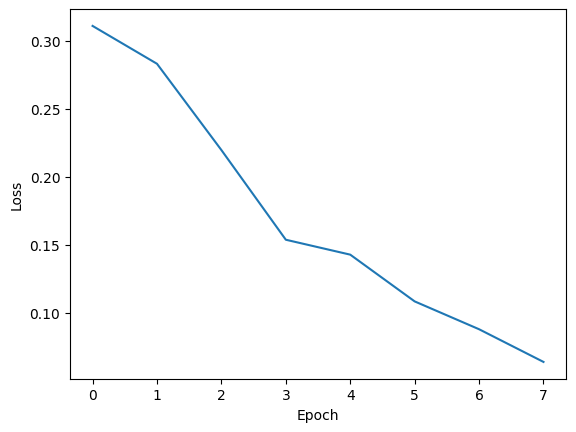

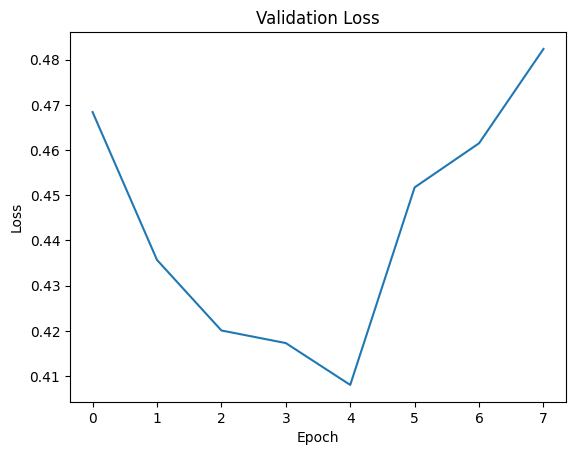

In [49]:
plt.ylabel("Loss")
plt.xlabel('Epoch')
plt.plot(train_history['loss'])
plt.show()

plt.title("Validation Loss")
plt.ylabel("Loss")
plt.xlabel('Epoch')
plt.plot(train_history['val_loss'])
plt.show()

In [33]:
Stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20,
    callbacks=[Stop]
    )

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6000 - loss: 0.6688 - val_accuracy: 0.6354 - val_loss: 0.6565
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5567 - loss: 0.6827 - val_accuracy: 0.6354 - val_loss: 0.6565
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6200 - loss: 0.6683 - val_accuracy: 0.6354 - val_loss: 0.6480
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6533 - loss: 0.6284 - val_accuracy: 0.6458 - val_loss: 0.6459
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5833 - loss: 0.6601 - val_accuracy: 0.6354 - val_loss: 0.6368
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6500 - loss: 0.6427 - val_accuracy: 0.6458 - val_loss: 0.6337
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6900 - loss: 0.6222 - val_accuracy: 0.6354 - val_loss: 0.6269
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.6600 - loss: 0.6200 - val_accuracy: 0.6562 - val_loss:

In [57]:
loss, accuracy = modelAPI.evaluate(test_generator)

print("Loss :", loss)
print("Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 661ms/step - accuracy: 0.8400 - loss: 0.5333
Loss : 0.5333405137062073
Accuracy : 0.8399999737739563


In [60]:
from sklearn.metrics import classification_report, confusion_matrix
pred_probs = modelAPI.predict(test_generator)
pred_classes = (pred_probs > 0.5).astype(int).flatten()
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))
cm = confusion_matrix(true_classes, pred_classes)
print(cm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 749ms/step
              precision    recall  f1-score   support

       crack       0.84      0.84      0.84        25
        dent       0.84      0.84      0.84        25

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.84      0.84      0.84        50

[[21  4]
 [ 4 21]]
